# Step 1: VAE for The Dataset (Without Balanced Sampling)




In [ ]:

import torch  
import torch.nn as nn  
import torch.nn.functional as F  
from torch.distributions import Normal, kl_divergence  
from torch.utils.data import TensorDataset, DataLoader  
import numpy as np 
import matplotlib.pyplot as plt  
import scanpy as sc 

from scvi.nn import Encoder, DecoderSCVI  
from scvi.distributions import ZeroInflatedNegativeBinomial 


torch.manual_seed(42)
np.random.seed(42)

print("✓ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

✓ All imports successful!
PyTorch version: 2.5.1+cu121
Device available: GPU (CUDA)


## Part 1: VAE Model Definition


In [ ]:
class scVAE_scvi(nn.Module):
    """
    Variational Autoencoder using scvi-tools components.
    
    This model learns a low-dimensional representation (latent space) of cells
    that captures the main patterns in gene expression.
    
    Architecture:
    Input (genes) → Encoder → Latent space (z) → Decoder → ZINB parameters
    
    Parameters:
    -----------
    n_genes : int
        Number of genes in your dataset (16,388 for your data)
    n_latent : int
        Dimensionality of latent space (default: 15, increased from typical 10)
        Higher = more capacity to capture complex patterns
    n_hidden : int
        Number of neurons in hidden layers (default: 256, increased from 128)
        Larger = better capacity for 16K genes
    n_layers : int
        Number of hidden layers (default: 2, increased from 1)
        Deeper = can learn more hierarchical features
    dropout_rate : float
        Dropout probability for regularization (default: 0.1)
        Helps prevent overfitting
    dispersion : str
        How dispersion parameter varies (default: 'gene')
        'gene' = one dispersion value per gene (most common)
    distribution : str
        Type of latent distribution (default: 'normal')
        'normal' = Gaussian prior (standard choice)
    use_batch_norm : bool
        Whether to use batch normalization (default: True)
        Helps with training stability
    use_layer_norm : bool
        Whether to use layer normalization (default: False)
    """
    def __init__(
        self,
        n_genes,
        n_latent=15,              
        n_hidden=256,             
        n_layers=2,               
        dropout_rate=0.1,
        dispersion='gene',
        distribution='normal',
        use_batch_norm=True,
        use_layer_norm=False,
    ):
        super().__init__()
        
        # Store configuration
        self.n_genes = n_genes
        self.n_latent = n_latent
        self.dispersion = dispersion
        self.distribution = distribution
        
        # =================================================================
        # ENCODER: Compresses gene expression → latent representation
        # =================================================================
        # This takes 16,388 genes and compresses to 15 latent dimensions
        # The encoder learns to capture the most important patterns
        self.z_encoder = Encoder(
            n_input=n_genes,           
            n_output=n_latent,        
            n_cat_list=None,           
            n_layers=n_layers,         
            n_hidden=n_hidden,        
            dropout_rate=dropout_rate, 
            distribution=distribution, 
            use_batch_norm=use_batch_norm,  
            use_layer_norm=use_layer_norm,  
        )
        
        # =================================================================
        # LIBRARY SIZE ENCODER: Encodes total counts per cell
        # =================================================================
        # Library size = total UMI counts per cell (sequencing depth)
        
        self.l_encoder = Encoder(
            n_input=n_genes,           
            n_output=1,               
            n_cat_list=None,         
            n_layers=1,               
            n_hidden=n_hidden,        
            dropout_rate=dropout_rate, 
            distribution='ln',        
            use_batch_norm=use_batch_norm,
            use_layer_norm=use_layer_norm,
        )
        
        # =================================================================
        # DECODER: Expands latent representation → gene expression
        # =================================================================
        # Takes 15 latent dimensions and predicts 16,388 gene expressions
        # Outputs parameters of ZINB distribution for each gene
        self.decoder = DecoderSCVI(
            n_input=n_latent,          
            n_output=n_genes,          
            n_cat_list=None,          
            n_layers=n_layers,         
            n_hidden=n_hidden,        
            use_batch_norm=use_batch_norm,
            use_layer_norm=use_layer_norm,
        )
        
        # =================================================================
        # DISPERSION PARAMETER: Controls variance in ZINB
        # =================================================================
        # Dispersion (θ) controls how much variance exceeds the mean
        # In negative binomial: variance = mean + mean²/θ
        # Higher θ = less overdispersion, lower θ = more overdispersion
        if dispersion == 'gene':
            # Learn one dispersion value per gene
            # Shape: (16,388,) - one parameter per gene
            self.px_r = nn.Parameter(torch.randn(n_genes))
        elif dispersion == 'gene-cell':
            # Dispersion varies per gene AND per cell
            pass
        else:
            raise ValueError(f"Dispersion '{dispersion}' not supported")
    
    def encode(self, x):
        """
        Encode gene expression into latent distribution parameters.
        
        Steps:
        1. Apply log1p transformation: log(1 + x)
           - Reduces skewness of count data
           - Numerical stability (avoids log(0))
        2. Pass through encoder network
        3. Get mean (μ), variance (σ²), and sample (z)
        
        Parameters:
        -----------
        x : torch.Tensor, shape (batch_size, n_genes)
            Raw gene counts
        
        Returns:
        --------
        qz_m : torch.Tensor, shape (batch_size, n_latent)
            Mean of latent posterior q(z|x)
        qz_v : torch.Tensor, shape (batch_size, n_latent)
            Variance of latent posterior q(z|x)
        z : torch.Tensor, shape (batch_size, n_latent)
            Sampled latent representation
        """
        x_ = torch.log1p(x)
        
        # Encoder returns: mean, variance, and a sample from N(mean, variance)
        qz_m, qz_v, z = self.z_encoder(x_)
        
        return qz_m, qz_v, z
    
    def encode_library(self, x):
        """
        Encode library size (total counts per cell).
        
        Library size follows a log-normal distribution.
        This helps account for differences in sequencing depth.
        
        Parameters:
        -----------
        x : torch.Tensor, shape (batch_size, n_genes)
            Raw gene counts
        
        Returns:
        --------
        ql_m : torch.Tensor, shape (batch_size, 1)
            Mean of log-library distribution
        ql_v : torch.Tensor, shape (batch_size, 1)
            Variance of log-library distribution
        library : torch.Tensor, shape (batch_size, 1)
            Sampled library size
        """
        x_ = torch.log1p(x)
        
        # Encode library size
        ql_m, ql_v, library = self.l_encoder(x_)
        
        return ql_m, ql_v, library
    
    def decode(self, z, library):
        """
        Decode latent representation to ZINB parameters.
        
        The ZINB distribution has three parameters:
        1. μ (mu): Mean expression level
        2. θ (theta): Dispersion (controls variance)
        3. π (pi): Dropout probability (zero-inflation)
        
        Parameters:
        -----------
        z : torch.Tensor, shape (batch_size, n_latent)
            Latent representation
        library : torch.Tensor, shape (batch_size, 1)
            Library size for each cell
        
        Returns:
        --------
        px_scale : torch.Tensor, shape (batch_size, n_genes)
            Normalized mean (before library scaling)
        px_r : torch.Tensor, shape (batch_size, n_genes)
            Dispersion parameter θ
        px_rate : torch.Tensor, shape (batch_size, n_genes)
            Actual mean μ (after library scaling)
        px_dropout : torch.Tensor, shape (batch_size, n_genes)
            Dropout probability π
        """
       
        # Decoder outputs ZINB parameters
        px_scale, px_r, px_rate, px_dropout = self.decoder(
            dispersion=self.dispersion,  
            z=z,                        
            library=library,           
        )
        
        # Handle dispersion parameter
        if self.dispersion == 'gene':
            
            px_r = self.px_r.view(1, -1).expand(z.size(0), -1)
        
        px_r = torch.exp(px_r)
        
        return px_scale, px_r, px_rate, px_dropout
    
    def forward(self, x):
        """
        Full forward pass through the VAE.
        
        Flow:
        1. Encode gene expression → latent parameters (μ, σ²)
        2. Sample latent representation z from N(μ, σ²)
        3. Encode library size
        4. Decode z → ZINB parameters (μ, θ, π)
        
        Parameters:
        -----------
        x : torch.Tensor, shape (batch_size, n_genes)
            Raw gene counts
        
        Returns:
        --------
        Dictionary containing:
        - ZINB parameters: px_scale, px_r, px_rate, px_dropout
        - Latent posterior: qz_m, qz_v, z
        - Library posterior: ql_m, ql_v, library
        """
        # Encode to latent space
        qz_m, qz_v, z = self.encode(x)
        
        # Encode library size
        ql_m, ql_v, library = self.encode_library(x)
        
        # Decode to ZINB parameters
        px_scale, px_r, px_rate, px_dropout = self.decode(z, library)
        
        return {
            # ZINB parameters for reconstruction
            'px_scale': px_scale,      # Normalized mean
            'px_r': px_r,              # Dispersion θ
            'px_rate': px_rate,        # Actual mean μ
            'px_dropout': px_dropout,  # Dropout probability π
            # Latent distribution
            'qz_m': qz_m,              # Latent mean
            'qz_v': qz_v,              # Latent variance
            'z': z,                    # Latent sample
            # Library distribution
            'ql_m': ql_m,              # Library mean
            'ql_v': ql_v,              # Library variance
            'library': library,        # Library sample
        }
    
    def loss(self, x, outputs):
        """
        Compute VAE loss (Evidence Lower Bound).
        
        The VAE loss has two components:
        
        1. Reconstruction Loss: How well can we reconstruct x from z?
           - Uses ZINB negative log-likelihood
           - Lower = better reconstruction
        
        2. KL Divergence: How different is q(z|x) from prior p(z)?
           - Regularizes the latent space
           - Keeps latent codes close to standard normal
           - Prevents overfitting
        
        Total Loss = Reconstruction Loss + KL Divergence
        
        Parameters:
        -----------
        x : torch.Tensor, shape (batch_size, n_genes)
            Observed gene counts
        outputs : dict
            Output from forward() containing all parameters
        
        Returns:
        --------
        loss : torch.Tensor, scalar
            Total loss (to minimize)
        recon_loss : torch.Tensor, scalar
            Reconstruction loss component
        kl_loss : torch.Tensor, scalar
            KL divergence component
        """
        # =====================================================================
        # RECONSTRUCTION LOSS (ZINB Negative Log-Likelihood)
        # =====================================================================
        # Create ZINB distribution with decoded parameters
      
        reconst_loss = ZeroInflatedNegativeBinomial(
            mu=outputs['px_rate'],       
            theta=outputs['px_r'],      
            zi_logits=outputs['px_dropout'],  
        ).log_prob(x) 
        
        # Negative log-likelihood

        recon_loss = -reconst_loss.sum(dim=-1).mean()
        
        # =====================================================================
        # KL DIVERGENCE (Latent Space Regularization)
        # =====================================================================
        
        # Define prior: standard normal distribution
        mean = torch.zeros_like(outputs['qz_m'])   
        scale = torch.ones_like(outputs['qz_v'])   
        
        # Compute KL divergence for latent variables
        kl_divergence_z = kl_divergence(
            Normal(outputs['qz_m'], torch.sqrt(outputs['qz_v'])),  
            Normal(mean, scale),                                    
        ).sum(dim=-1)  
        
        # Compute KL divergence for library size
        kl_divergence_l = kl_divergence(
            Normal(outputs['ql_m'], torch.sqrt(outputs['ql_v'])),
            Normal(mean[:, :1], scale[:, :1]),
        ).sum(dim=-1)
        
        kl_loss = (kl_divergence_z + kl_divergence_l).mean()
        
        loss = recon_loss + kl_loss
        
        return loss, recon_loss, kl_loss

## Part 2: Data Preparation



In [ ]:
def prepare_data_for_vae(adata, batch_size=256, test_split=0.1):
    """
    Prepare AnnData for VAE training.
    
    Steps:
    1. Extract count matrix from AnnData
    2. Convert to PyTorch tensors
    3. Split into train and test sets
    4. Create DataLoaders for batching
    
    Parameters:
    -----------
    adata : AnnData
        Scanpy AnnData object with raw counts in .X
    batch_size : int
        Number of cells per batch (default: 256)
    test_split : float
        Fraction of data for testing (default: 0.1 = 10%)
    
    Returns:
    --------
    train_loader : DataLoader
        Training data
    test_loader : DataLoader
        Test data for validation
    """
   
    if hasattr(adata.layers['counts'], 'toarray'):
        X = adata.layers['counts'].toarray()
    else:
        X = adata.layers['counts']
    
    print("="*60)
    print("Data Preparation")
    print("="*60)
    print(f"Total cells: {X.shape[0]:,}")
    print(f"Total genes: {X.shape[1]:,}")
    print(f"Matrix type: {'Sparse' if hasattr(adata.X, 'toarray') else 'Dense'}")
    print(f"Memory size: {X.nbytes / 1e6:.1f} MB")
    
    X_tensor = torch.FloatTensor(X)
    
    # Split into train and test
    n_cells = X.shape[0]
    n_test = int(n_cells * test_split)
    n_train = n_cells - n_test
    
    # Random permutation for splitting
    indices = torch.randperm(n_cells)
    train_idx = indices[:n_train]
    test_idx = indices[n_train:]
    
    print(f"\nTrain cells: {n_train:,} ({100*n_train/n_cells:.1f}%)")
    print(f"Test cells: {n_test:,} ({100*n_test/n_cells:.1f}%)")
    print(f"Batch size: {batch_size}")
    print(f"Batches per epoch: {n_train // batch_size}")
    print("="*60 + "\n")
    
    # Create datasets
    train_dataset = TensorDataset(X_tensor[train_idx])
    test_dataset = TensorDataset(X_tensor[test_idx])
    
    # Create data loaders
    # DataLoader handles batching and shuffling
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,  
        num_workers=0 
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  
        num_workers=0
    )
    
    return train_loader, test_loader

## Part 3: Training Function



In [ ]:
def train_vae(model, train_loader, test_loader=None, n_epochs=150, lr=1e-3,
              device='cpu', patience=20, gradient_clip=1.0):
    """
    Train the VAE model.
    
    Training loop:
    1. Forward pass: x → model → outputs
    2. Compute loss: reconstruction + KL
    3. Backward pass: compute gradients
    4. Update: adjust model parameters
    5. Repeat for all batches (1 epoch)
    6. Validate on test set
    7. Check early stopping criteria
    
    Parameters:
    -----------
    model : scVAE_scvi
        VAE model to train
    train_loader : DataLoader
        Training data
    test_loader : DataLoader, optional
        Test data for validation
    n_epochs : int
        Maximum number of epochs (default: 150)
        One epoch = one pass through all training data
    lr : float
        Learning rate (default: 1e-3 = 0.001)
        Controls size of parameter updates
    device : str
        'cpu' or 'cuda' for GPU
    patience : int
        Early stopping patience (default: 20)
        Stop if no improvement for this many epochs
    gradient_clip : float
        Gradient clipping value (default: 1.0)
        Prevents exploding gradients
    
    Returns:
    --------
    history : dict
        Training history (losses per epoch)
    """
    model = model.to(device)
    
    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',      
        factor=0.5,      
        patience=10,    
        verbose=True    
    )
    
    history = {
        'total_loss': [],   
        'recon_loss': [],    
        'kl_loss': [],      
        'test_loss': [],    
    }
    
    best_loss = float('inf')  
    patience_counter = 0      
    
    print("\n" + "="*60)
    print("Starting Training")
    print("="*60)
    print(f"Device: {device}")
    print(f"Initial learning rate: {lr}")
    print(f"Batch size: {train_loader.batch_size}")
    print(f"Batches per epoch: {len(train_loader)}")
    print(f"Max epochs: {n_epochs}")
    print(f"Early stopping patience: {patience}")
    print("="*60 + "\n")
    
    save_path = 'models/vae_models/best_vae_model.pt'

    for epoch in range(n_epochs):
        # =====================================================================
        # TRAINING PHASE
        # =====================================================================
        model.train()  
        
        epoch_total = 0
        epoch_recon = 0
        epoch_kl = 0
        
        for batch_idx, (x,) in enumerate(train_loader):
            x = x.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(x)
            
            loss, recon_loss, kl_loss = model.loss(x, outputs)
          
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)

            optimizer.step()
   
            epoch_total += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
        
        # Compute epoch averages
        n_batches = len(train_loader)
        avg_total = epoch_total / n_batches
        avg_recon = epoch_recon / n_batches
        avg_kl = epoch_kl / n_batches
        
        # Store in history
        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)
        
        # =====================================================================
        # VALIDATION PHASE
        # =====================================================================
        
        if test_loader is not None:
            model.eval()  
            test_total = 0
            
            with torch.no_grad():
                for (x,) in test_loader:
                    x = x.to(device)
                    outputs = model(x)
                    loss, _, _ = model.loss(x, outputs)
                    test_total += loss.item()
            
            avg_test = test_total / len(test_loader)
            history['test_loss'].append(avg_test)
            
            scheduler.step(avg_test)
            
            if avg_test < best_loss:

                best_loss = avg_test

                patience_counter = 0

                torch.save(model.state_dict(), save_path)
            else:
                patience_counter += 1
        else:
            scheduler.step(avg_total)
            if avg_total < best_loss:
                best_loss = avg_total
                patience_counter = 0
                torch.save(model.state_dict(), save_path)
            else:
                patience_counter += 1
        
      
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs}")
            print(f"  Train Loss: {avg_total:.4f} "
                  f"(Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
            if test_loader is not None:
                print(f"  Test Loss:  {avg_test:.4f}")
            print(f"  Best Loss:  {best_loss:.4f} "
                  f"(Patience: {patience_counter}/{patience})")
            print()
        
        # =====================================================================
        # EARLY STOPPING
        # =====================================================================
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"No improvement for {patience} epochs")
            print(f"Best loss: {best_loss:.4f}")
            break
    
    # Load best model
    print("\n" + "="*60)
    print("Training Complete!")
    print("="*60)
    print(f"Loading best model (loss: {best_loss:.4f})")
    model.load_state_dict(torch.load(save_path))
    print("✓ Best model loaded")
    print("="*60 + "\n")
    
    return history

## Part 4: Helper Functions

In [ ]:
def get_latent_representation(model, data_loader, device='cpu'):
    """
    Extract latent representations for all cells.
    
    This runs the encoder on all data to get the latent space coordinates.
    Useful for:
    - Visualization (UMAP, t-SNE)
    - Clustering
    - Trajectory inference
    - Downstream analysis
    
    Parameters:
    -----------
    model : scVAE_scvi
        Trained VAE model
    data_loader : DataLoader
        Data to encode
    device : str
        'cpu' or 'cuda'
    
    Returns:
    --------
    z_mean : np.ndarray, shape (n_cells, n_latent)
        Mean latent representation for each cell
        More stable than samples (no sampling noise)
    z_sample : np.ndarray, shape (n_cells, n_latent)
        Sampled latent representation for each cell
        Includes sampling variability
    """
    model = model.to(device)
    model.eval()  
    
    z_means = []
    z_samples = []
    
    with torch.no_grad():
        for (x,) in data_loader:
            x = x.to(device)
            
            outputs = model(x)
           
            z_means.append(outputs['qz_m'].cpu().numpy())
            z_samples.append(outputs['z'].cpu().numpy())
    
    z_mean = np.vstack(z_means)
    z_sample = np.vstack(z_samples)
    
    print(f"Extracted latent representations:")
    print(f"  Shape: {z_mean.shape}")
    print(f"  (n_cells, n_latent) = ({z_mean.shape[0]:,}, {z_mean.shape[1]})")
    
    return z_mean, z_sample


def plot_training_history(history):
    """
    Visualize training progress.
    
    Parameters:
    -----------
    history : dict
        Training history from train_vae()
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Total loss
    axes[0].plot(history['total_loss'], label='Train', linewidth=2)
    if history['test_loss']:  
        axes[0].plot(history['test_loss'], label='Test', linewidth=2)
        axes[0].legend()
    axes[0].set_title('Total Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Reconstruction loss
    axes[1].plot(history['recon_loss'], color='orange', linewidth=2)
    axes[1].set_title('Reconstruction Loss (ZINB)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: KL divergence
    axes[2].plot(history['kl_loss'], color='green', linewidth=2)
    axes[2].set_title('KL Divergence', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/vae_figures_step1/vae_train_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nFinal Training Statistics:")
    print(f"  Final train loss: {history['total_loss'][-1]:.4f}")
    if history['test_loss']:
        print(f"  Final test loss:  {history['test_loss'][-1]:.4f}")
    print(f"  Final recon loss: {history['recon_loss'][-1]:.4f}")
    print(f"  Final KL loss:    {history['kl_loss'][-1]:.4f}")


def visualize_latent_space(adata, color_by='cell_type', basis='X_vae'):
    """
    Visualize latent space with UMAP.
    
    Steps:
    1. Compute neighbors in latent space
    2. Run UMAP for 2D visualization
    3. Plot colored by metadata
    
    Parameters:
    -----------
    adata : AnnData
        AnnData with latent representation in .obsm[basis]
    color_by : str or list
        Column(s) in adata.obs to color by
    basis : str
        Key in .obsm for latent representation
    """
    print("\nVisualizing latent space...")
    
    # Compute neighbor graph in latent space
    # use_rep: which representation to use
    print("  Computing neighbors...")
    sc.pp.neighbors(adata, use_rep=basis, n_neighbors=15)
    
    # Run UMAP for 2D visualization
    print("  Running UMAP...")
    sc.tl.umap(adata)
    
    print("  Plotting...")
    sc.pl.umap(
        adata,
        color=color_by,
        frameon=False,  
        size=10,        
        ncols=2         
    )
    plt.tight_layout()
    plt.savefig('outputs/vae_figures_step1/latent_space.png', dpi=300, bbox_inches='tight')
   

## Part 5: Complete Training Pipeline



In [ ]:

import os 
os.makedirs('models/vae_models', exist_ok=True)
os.makedirs('outputs/vae_figures_step1', exist_ok=True)   
ADATA_PATH = 'models/tumor_normal_integrated.h5ad'

adata= sc.read_h5ad(ADATA_PATH)
print(adata)
print(adata.obs.columns)  

AnnData object with n_obs × n_vars = 103426 × 16388
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'batch', 'condition', 'dataset', '_scvi_batch', '_scvi_labels', 'leiden_scvi'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scvi', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'distances'
Index(['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'n_genes', 'batch', 'condition', 'dataset', '_scvi_batch',
       '_scvi_labels', 'leiden_scvi'],
      dtype='object')


In [ ]:
# =============================================================================
# STEP 1: Prepare Data
# =============================================================================
# Convert AnnData to PyTorch DataLoaders

train_loader, test_loader = prepare_data_for_vae(
    adata,
    batch_size=256,    
    test_split=0.1     
)

Data Preparation
Total cells: 103,426
Total genes: 16,388
Matrix type: Sparse
Memory size: 6779.8 MB

Train cells: 93,084 (90.0%)
Test cells: 10,342 (10.0%)
Batch size: 256
Batches per epoch: 363



In [ ]:
# =============================================================================
# STEP 2: Initialize Model
# =============================================================================
# Create VAE with optimized parameters for your dataset

model = scVAE_scvi(
    n_genes=adata.n_vars,    
    n_latent=15,            
    n_hidden=256,            
    n_layers=2,             
    dropout_rate=0.1,        
    dispersion='gene',       
    distribution='normal',   
    use_batch_norm=True,     
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*60)
print("Model Information")
print("="*60)
print(f"Device: {device}")
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"Model size (approx): {n_params * 4 / 1e6:.1f} MB")
print("="*60 + "\n")


Model Information
Device: cuda
Total parameters: 21,189,168
Trainable parameters: 21,189,168
Model size (approx): 84.8 MB



In [ ]:
# =============================================================================
# STEP 3: Train Model
# =============================================================================
# Train with optimized settings

history = train_vae(
    model,
    train_loader,
    test_loader=test_loader,
    n_epochs=150,           
    lr=1e-3,               
    device=device,
    patience=20,           
    gradient_clip=1.0       
)

c:\Users\monster\miniconda3\envs\bio\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Starting Training
Device: cuda
Initial learning rate: 0.001
Batch size: 256
Batches per epoch: 364
Max epochs: 150
Early stopping patience: 20

Epoch   1/150
  Train Loss: 134916.7822 (Recon: 134889.2753, KL: 27.5073)
  Test Loss:  128757.5955
  Best Loss:  128757.5955 (Patience: 0/20)

Epoch  10/150
  Train Loss: 85584.4559 (Recon: 85541.4516, KL: 43.0043)
  Test Loss:  83035.3472
  Best Loss:  83035.3472 (Patience: 0/20)

Epoch  20/150
  Train Loss: 50404.3670 (Recon: 50365.0055, KL: 39.3614)
  Test Loss:  49962.5374
  Best Loss:  49962.5374 (Patience: 0/20)

Epoch  30/150
  Train Loss: 34256.4214 (Recon: 34222.3534, KL: 34.0680)
  Test Loss:  34953.8144
  Best Loss:  34953.8144 (Patience: 0/20)

Epoch  40/150
  Train Loss: 29661.6535 (Recon: 29631.7268, KL: 29.9267)
  Test Loss:  30467.6694
  Best Loss:  30467.6694 (Patience: 0/20)

Epoch  50/150
  Train Loss: 28504.1935 (Recon: 28476.3983, KL: 27.7952)
  Test Loss:  29224.9366
  Best Loss:  29224.9366 (Patience: 0/20)

Epoch  60/1

C:\Users\monster\AppData\Local\Temp\ipykernel_8076\1060041330.py:215: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


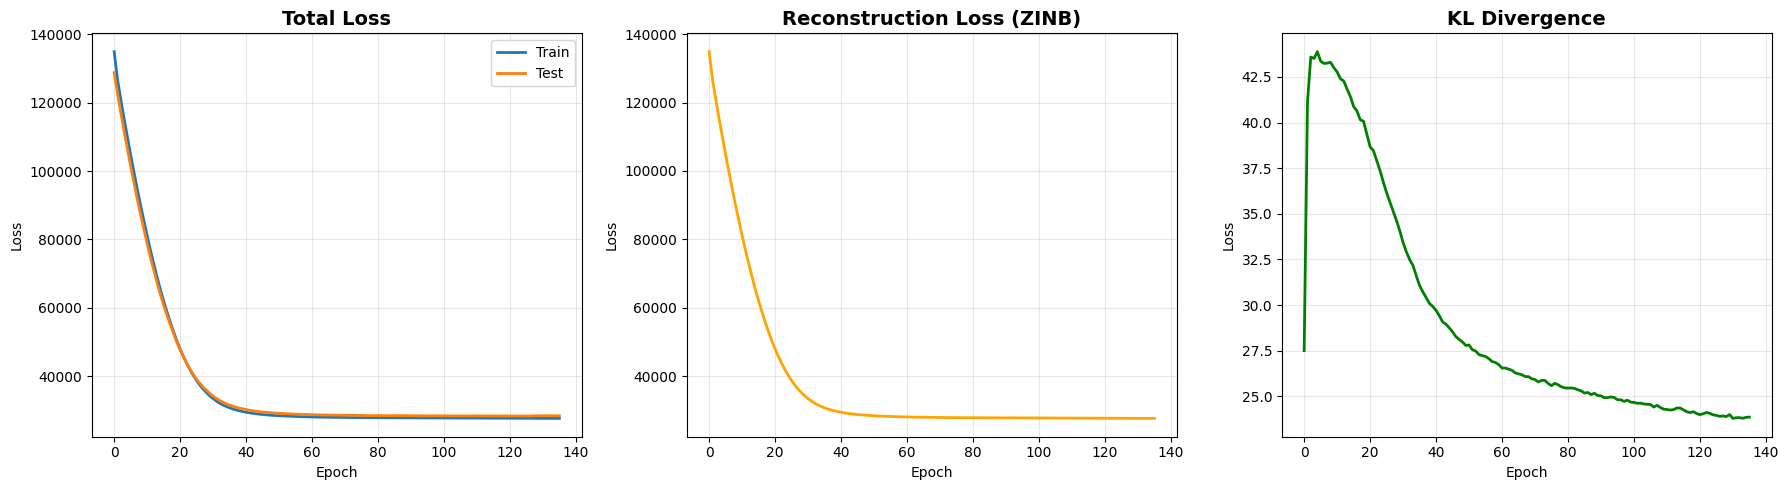


Final Training Statistics:
  Final train loss: 27683.8566
  Final test loss:  28440.5248
  Final recon loss: 27659.9935
  Final KL loss:    23.8631


In [ ]:
# =============================================================================
# STEP 4: Visualize Training
# =============================================================================

plot_training_history(history)

In [ ]:
# =============================================================================
# STEP 5: Extract Latent Representations
# =============================================================================
# Get latent space coordinates for all cells

if hasattr(adata.layers['counts'], 'toarray'):
    X_all = adata.layers['counts'].toarray()
else:
    X_all = adata.layers['counts']

X_all_tensor = torch.FloatTensor(X_all)
full_dataset = TensorDataset(X_all_tensor)
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=False)

print("\nExtracting latent representations...")
z_mean, z_sample = get_latent_representation(model, full_loader, device)

adata.obsm['X_vae'] = z_mean

print("\n✓ Added to adata.obsm['X_vae']")



Extracting latent representations...
Extracted latent representations:
  Shape: (103426, 15)
  (n_cells, n_latent) = (103,426, 15)

✓ Added to adata.obsm['X_vae']
  You can now use this for:
  - UMAP visualization
  - Clustering
  - Trajectory inference
  - Downstream analysis



Visualizing latent space...
  Computing neighbors...
  Running UMAP...
  Plotting...


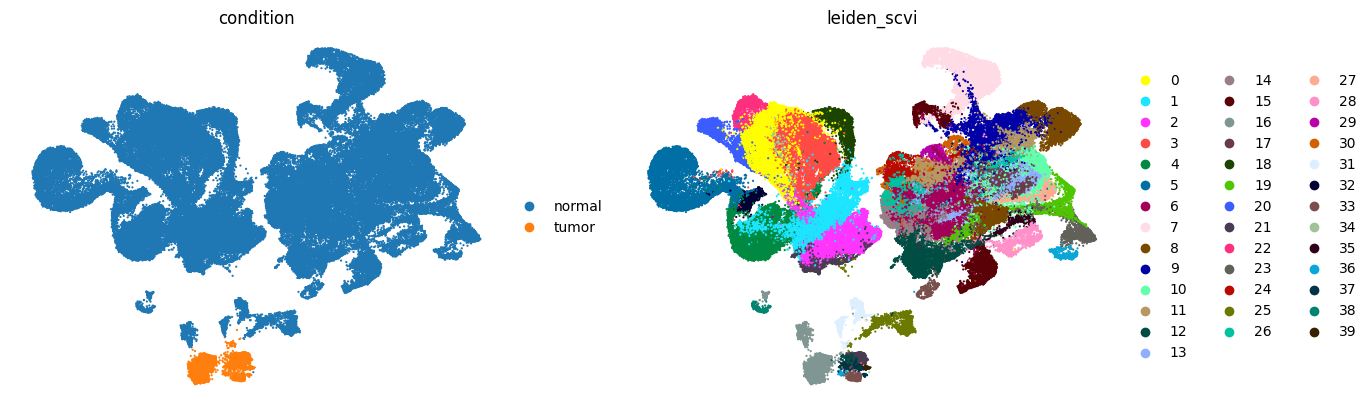

✓ Done!


In [ ]:
# =============================================================================
# STEP 6: Visualize Latent Space
# =============================================================================
# Create UMAP visualization

visualize_latent_space(
    adata,
    color_by=['condition', 'leiden_scvi'],
    basis='X_vae'
)

## Part 6: Evaluation 


## Optional: Save Your Results

In [ ]:

adata.write('data/adata_with_vae_latent.h5ad')

KeyboardInterrupt: 

---

# Model Loading Section


---

In [ ]:

TRAIN_MODE = False  # True: Train from scratch | False: Load pre-trained model

ADATA_PATH = 'models/tumor_normal_integrated.h5ad'  
MODEL_PATH = 'models/best_vae_model.pt'  
OUTPUT_DIR = 'outputs/vae_figures_step1'  

N_EPOCHS = 150
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 20

N_LATENT = 15
N_HIDDEN = 256
N_LAYERS = 2

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("="*60)
print("STEP 1 CONFIGURATION")
print("="*60)
print(f"\nMode: {'TRAIN' if TRAIN_MODE else 'LOAD & VISUALIZE'}")
print(f"Data: {ADATA_PATH}")
print(f"Model: {MODEL_PATH}")
if TRAIN_MODE:
    print(f"\nTraining params:")
    print(f"  Epochs: {N_EPOCHS}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Latent dims: {N_LATENT}")
else:
    if os.path.exists(MODEL_PATH):
        print(f"\n✓ Model found: {MODEL_PATH}")
    else:
        print(f"\n Model not found: {MODEL_PATH}")
        print(f"   Set TRAIN_MODE=True to train first!")
print("="*60 + "\n")

STEP 1 CONFIGURATION

Mode: LOAD & VISUALIZE
Data: models/tumor_normal_integrated.h5ad
Model: models/best_vae_model.pt

✓ Model found: models/best_vae_model.pt



In [ ]:

if not TRAIN_MODE:
    print("\n" + "="*60)
    print("Loading Pre-Trained Model")
    print("="*60)
    
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Model not found: {MODEL_PATH}\n"
            f"Set TRAIN_MODE=True to train first!"
        )
    
    print(f"\nInitializing model architecture...")
    model = scVAE_scvi(
        n_genes=adata.n_vars,
        n_latent=N_LATENT,
        n_hidden=N_HIDDEN,
        n_layers=N_LAYERS,
        dropout_rate=0.1,
        dispersion='gene',
        distribution='normal',
        use_batch_norm=True,
    )
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Loading weights from: {MODEL_PATH}")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    
    print(f"✓ Model loaded!")
    print(f"  Device: {device}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    print("\nExtracting latent space...")
    from tqdm import tqdm
    
    if hasattr(adata.layers['counts'], 'toarray'):
        X = adata.layers['counts'].toarray()
    else:
        X = adata.layers['counts']
    
    X_tensor = torch.FloatTensor(X)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=512, shuffle=False)
    
    z_means = []
    with torch.no_grad():
        for (x,) in tqdm(loader, desc="Extracting"):
            x = x.to(device)
            qz_m, qz_v, z = model.encode(x)
            z_means.append(qz_m.cpu().numpy())
    
    X_vae = np.vstack(z_means)
    adata.obsm['X_vae'] = X_vae
    
    print(f"✓ Extracted X_vae: {X_vae.shape}")
    print("="*60)
    
else:
    print("\n✓ Model already trained in this session")


Loading Pre-Trained Model

Initializing model architecture...
Loading weights from: models/best_vae_model.pt


C:\Users\monster\AppData\Local\Temp\ipykernel_21256\2457223009.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location

✓ Model loaded!
  Device: cuda
  Parameters: 21,189,168

Extracting latent space...


Extracting: 100%|██████████| 203/203 [00:05<00:00, 39.39it/s]

✓ Extracted X_vae: (103426, 15)


In [11]:
# =============================================================================
# COMPUTE UMAP
# =============================================================================

print("\n" + "="*60)
print("Computing UMAP")
print("="*60)

if 'X_vae' not in adata.obsm:
    raise ValueError("X_vae not found! Train or load model first.")

print("\nComputing neighbors...")
sc.pp.neighbors(adata, use_rep='X_vae', n_neighbors=15)

print("Computing UMAP...")
sc.tl.umap(adata)

print("✓ UMAP computed!")
print("="*60)


Computing UMAP

Computing neighbors...
Computing UMAP...
✓ UMAP computed!


In [ ]:
# =============================================================================
# STEM MARKERS
# =============================================================================

print("\n" + "="*60)
print("Stem Marker Visualization")
print("="*60)

stem_markers = [
    'SOX2', 'NES', 'VIM', 'OLIG2', 'FABP7', 'ASCL1',
    'PROM1', 'CD44', 'NOTCH1', 'HES1', 'PAX6', 'BMI1'
]

available_markers = [m for m in stem_markers if m in adata.var_names]

print(f"\nFound {len(available_markers)}/{len(stem_markers)} markers:")
if len(available_markers) > 0:
    print(f"  {', '.join(available_markers)}")
else:
    print(" No markers found!")

print("="*60)


Stem Marker Visualization

Found 12/12 markers:
  SOX2, NES, VIM, OLIG2, FABP7, ASCL1, PROM1, CD44, NOTCH1, HES1, PAX6, BMI1



Plotting UMAP by condition...


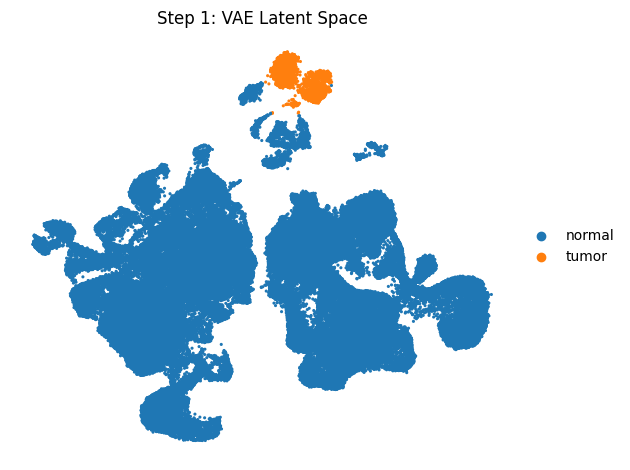

✓ Saved: figures/umap_step1_condition.png


In [ ]:
# =============================================================================
# PLOT: CONDITION
# =============================================================================

print("\nPlotting UMAP by condition...")

sc.pl.umap(
    adata,
    color='condition',
    frameon=False,
    size=20,
    title='Step 1: VAE Latent Space',
    show=False
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step1_condition.png', 
                dpi=300, bbox_inches='tight')

plt.show()

print("✓ Saved: outputs/umap_step1_condition.png")


Plotting individual markers...


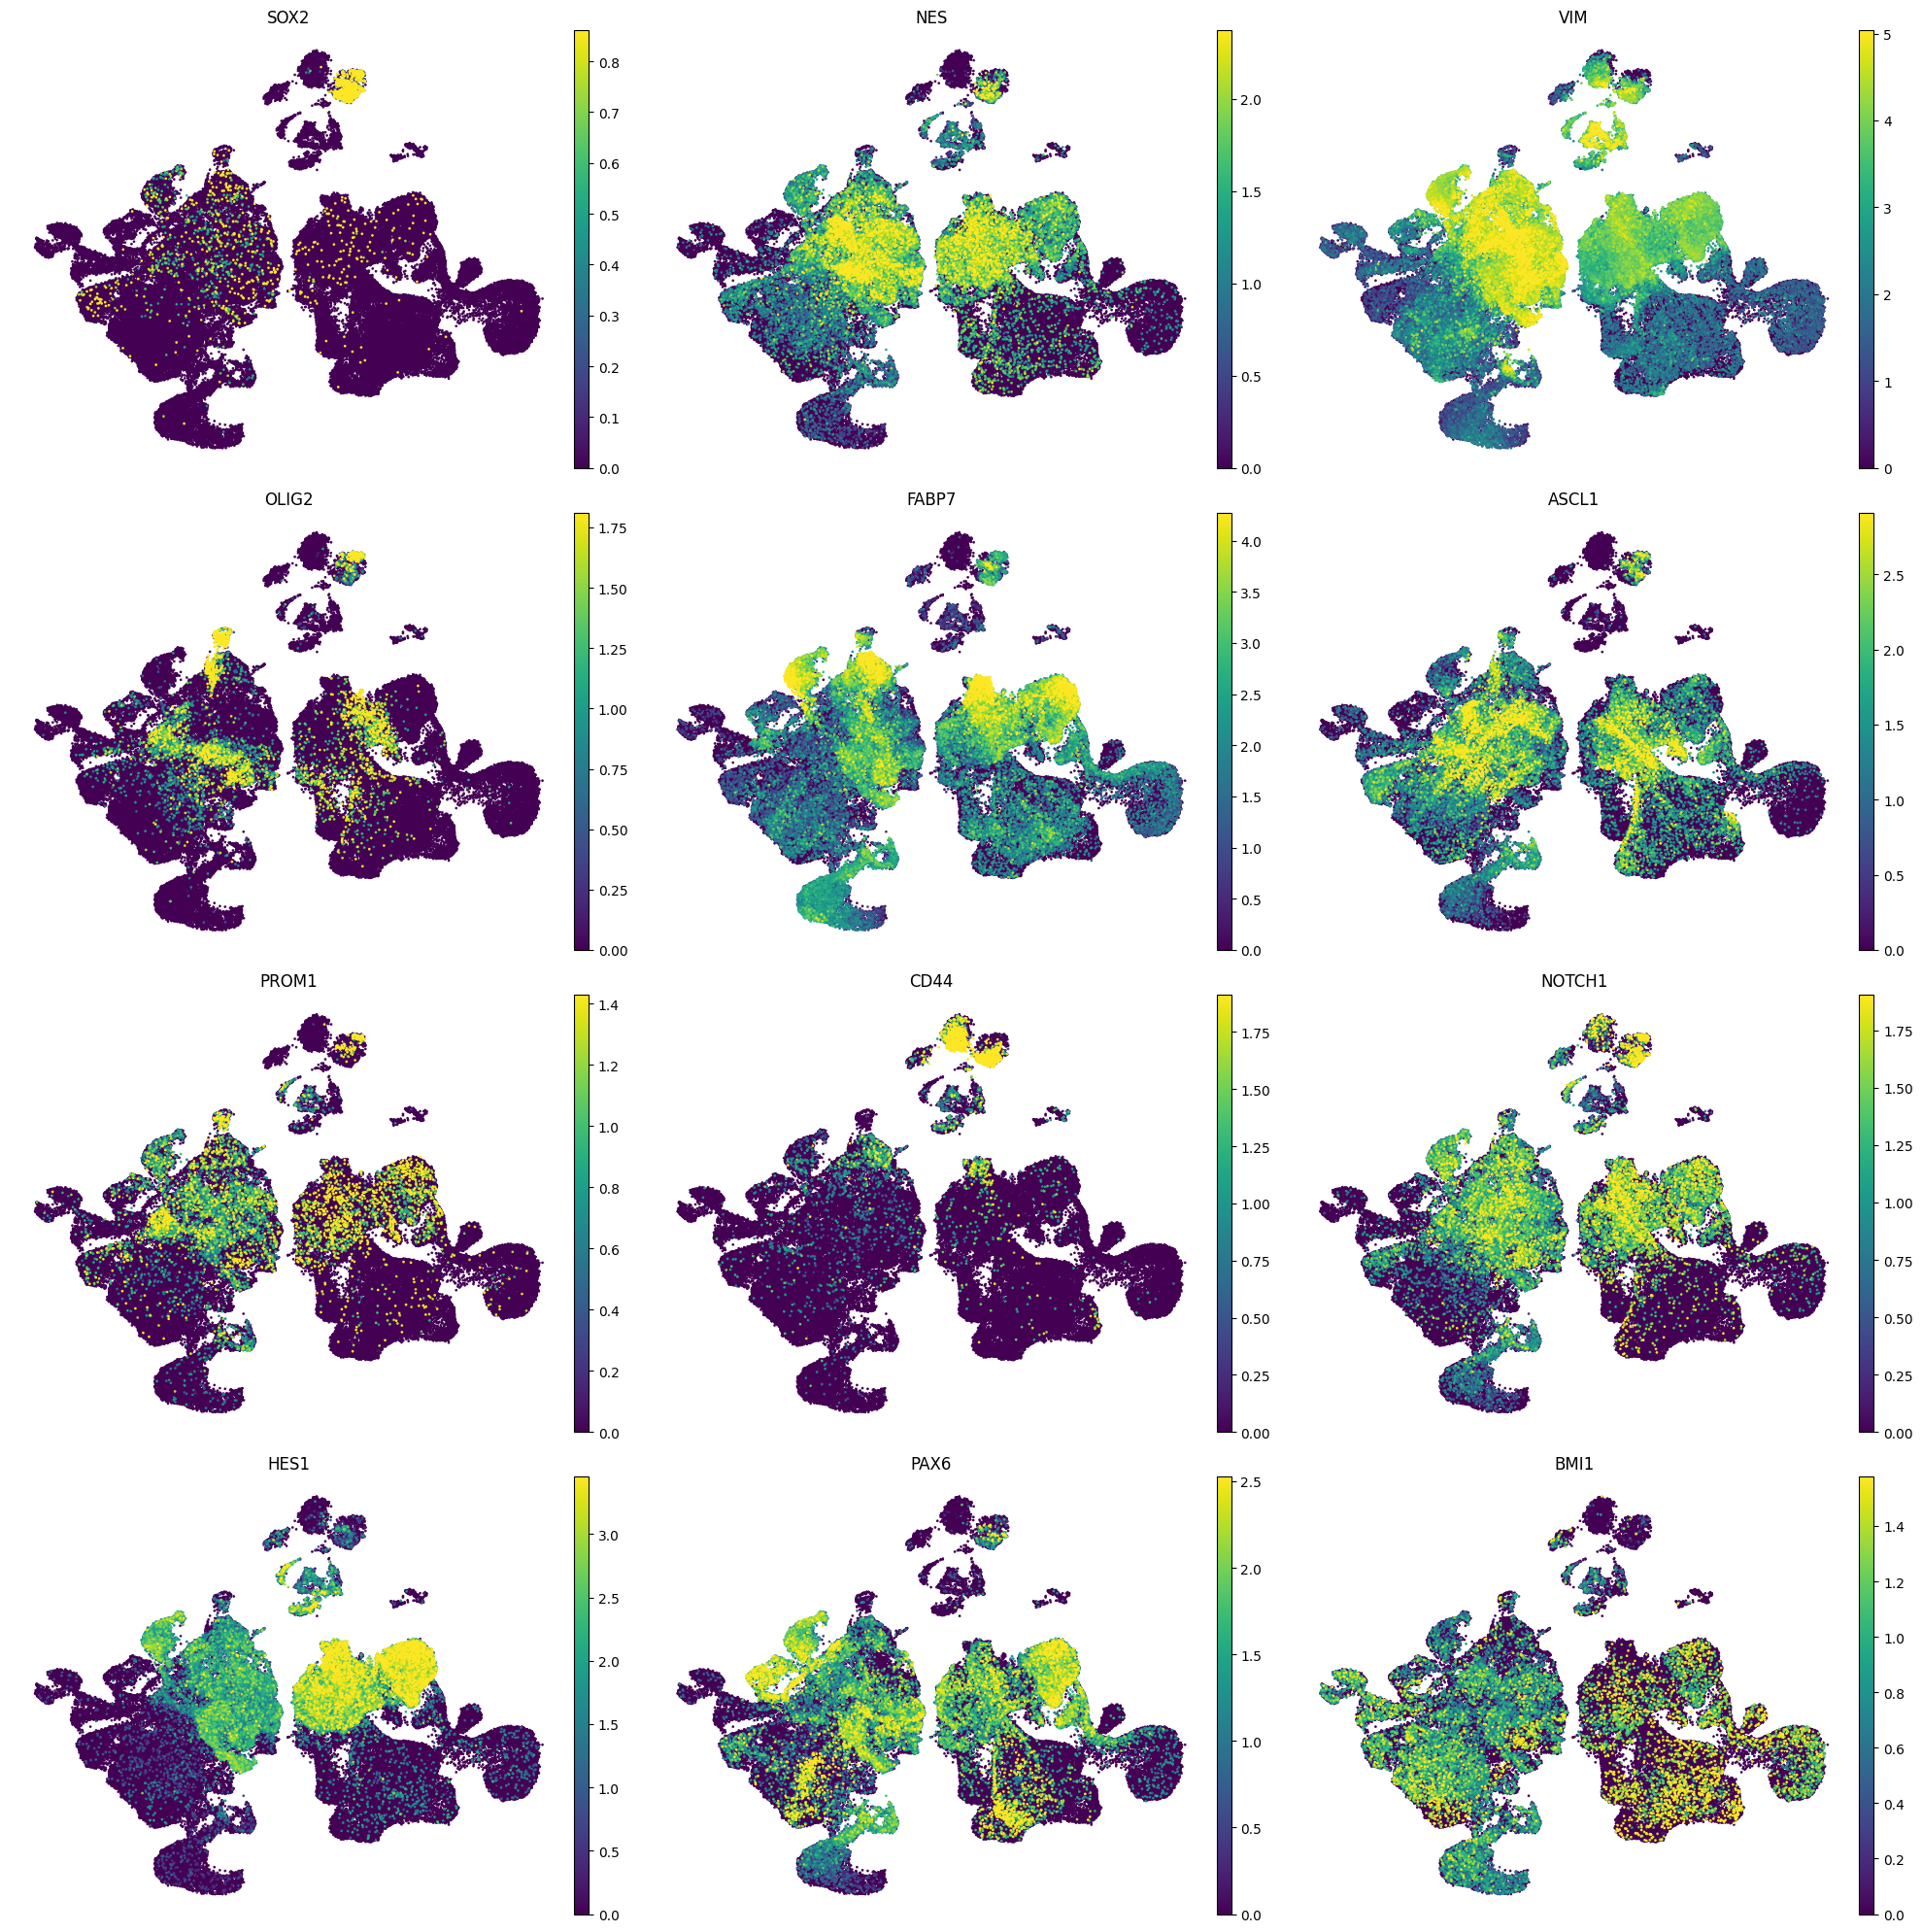

✓ Saved: outputs/vae_figures_step1/step1_markers.png


In [14]:
# =============================================================================
# PLOT: INDIVIDUAL MARKERS
# =============================================================================

if len(available_markers) > 0:
    print("\nPlotting individual markers...")
    
    import matplotlib.pyplot as plt
    
    ncols = 3
    nrows = int(np.ceil(len(available_markers) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, marker in enumerate(available_markers):
        sc.pl.embedding(
            adata, basis='umap', color=marker,
            ax=axes[idx], title=f'{marker}',
            show=False, frameon=False, size=15,
            vmin='p1', vmax='p99'
        )
    
    for idx in range(len(available_markers), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/step1_markers.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {OUTPUT_DIR}/step1_markers.png")


Computing stem score...
✓ Stem score: [0.000, 0.395]


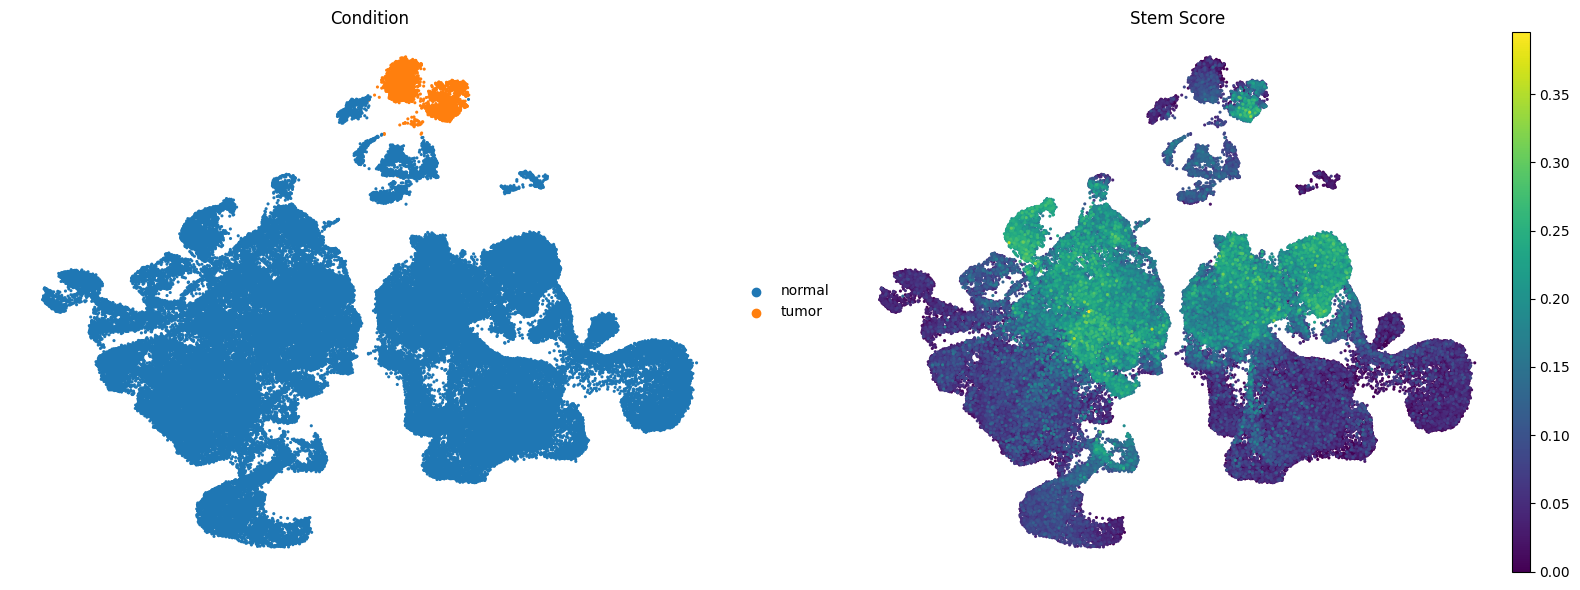

✓ Saved: outputs/vae_figures_step1/step1_stem_score.png

Stem Score by Condition:
  tumor: 0.080 ± 0.063
  normal: 0.086 ± 0.069

✓ Saved: outputs/vae_figures_step1/step1_stem_scores.csv


In [ ]:
# =============================================================================
# STEM SCORE
# =============================================================================

if len(available_markers) > 0:
    print("\nComputing stem score...")
    
    if hasattr(adata.X, 'toarray'):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    marker_indices = [list(adata.var_names).index(m) for m in available_markers]
    marker_expr = X[:, marker_indices]
    
    marker_expr_norm = np.zeros_like(marker_expr, dtype=float)
    for i in range(len(marker_indices)):
        expr = marker_expr[:, i]
        min_val, max_val = expr.min(), expr.max()
        if max_val > min_val:
            marker_expr_norm[:, i] = (expr - min_val) / (max_val - min_val)
    
    stem_score = marker_expr_norm.mean(axis=1)
    adata.obs['stem_score'] = stem_score
    
    print(f"✓ Stem score: [{stem_score.min():.3f}, {stem_score.max():.3f}]")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sc.pl.embedding(adata, basis='umap', color='condition',
                   ax=axes[0], title='Condition', show=False, frameon=False, size=20)
    sc.pl.embedding(adata, basis='umap', color='stem_score',
                   ax=axes[1], title='Stem Score', show=False, frameon=False,
                   size=20, cmap='viridis')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/step1_stem_score.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {OUTPUT_DIR}/step1_stem_score.png")
    
    from scipy.stats import ttest_ind
    print("\nStem Score by Condition:")
    for cond in adata.obs['condition'].unique():
        mask = adata.obs['condition'] == cond
        scores = adata.obs.loc[mask, 'stem_score']
        print(f"  {cond}: {scores.mean():.3f} ± {scores.std():.3f}")
    
    adata.obs[['stem_score']].to_csv(f'{OUTPUT_DIR}/step1_stem_scores.csv')
    print(f"\n✓ Saved: {OUTPUT_DIR}/step1_stem_scores.csv")

In [ ]:
# =============================================================================
# SAVE RESULTS
# =============================================================================

print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Save model (if trained)
if TRAIN_MODE and 'model' in globals():
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"✓ Saved model: {MODEL_PATH}")

# Save latent space separately
if 'X_vae' in adata.obsm:
    np.save(f'{OUTPUT_DIR}/X_vae_step1.npy', adata.obsm['X_vae'])
    np.save(f'{OUTPUT_DIR}/X_vae_step1_cell_names.npy', adata.obs_names.to_numpy())
    print(f"✓ Saved: {OUTPUT_DIR}/X_vae_step1.npy ({adata.obsm['X_vae'].nbytes/1e6:.1f} MB)")

# Save history (if trained)
if TRAIN_MODE and 'history' in globals():
    import pickle
    with open(f'{OUTPUT_DIR}/step1_history.pkl', 'wb') as f:
        pickle.dump(history, f)
    print(f"✓ Saved history: {OUTPUT_DIR}/step1_history.pkl")

print("\n✓ All results saved!")
print("="*60)



Saving Results
✓ Saved: outputs/vae_figures_step1/X_vae_step1.npy (6.2 MB)

✓ All results saved!

STEP 1 COMPLETE!

Mode: LOADED

Next: Step 2 (Stem marker similarities)

